In [1]:


import numpy as np
import matplotlib.pyplot as plt

def load_arrays(filename):
    """Reads the file and sorts the data in to two arrays"""
    data = np.loadtxt(filename, comments = '#')  # Loads text file, comments excludes anything starting with the given input
    x = np.array(data)
    return x
    
filename = "m101BW.jpg"
x = load_arrays(filename)

plt.imshow(x, cmap = 'jet')
plt.show()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte

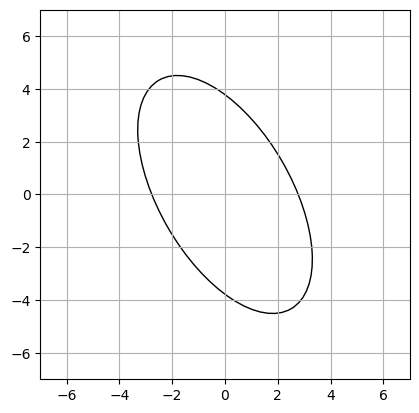

In [2]:
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
     def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
         
from matplotlib.pyplot import show, figure
fig = figure()
frame = fig.add_subplot(1,1,1, aspect=1)
xcenter = 0.0
ycenter = 0.0
semimajor = 5;
semiminor= 2.5
theta = 30.0    # degrees, anti clockwise
ell = AstroEllipse(xcenter, ycenter, semimajor, semiminor, theta, fill=False)
frame.add_patch(ell)
frame.set_xlim(-7,7)    # Limits are not automatically adjusted when patches are used
frame.set_ylim(-7,7)
frame.grid()
show()

In [3]:
# Calculating the Keplarian rotation curve
condition = (R <= 0)
r = ma.masked_array(R, condition)
velocity = np.sqrt((G*M)/r)

# Saving values of Keplarian velocities
np.savetxt('keplarian_curve.txt', velocity, fmt='%.18e', delimiter=' ', newline='\n',
              header='', footer='', comments='# ')

kc = np.loadtxt('keplarian_curve.txt', comments = '#')
plt.plot(kc)
plt.show()


NameError: name 'R' is not defined

/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


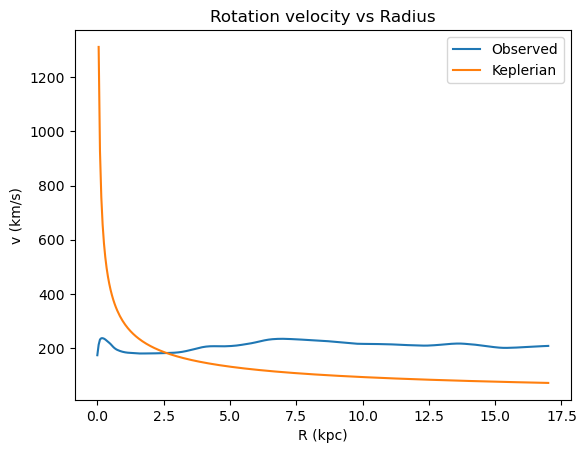

In [7]:
from astropy.constants import G, M_sun
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

M = 2e10 * M_sun
def load_arrays(filename):
    """Reads the file and sorts the data in to two arrays"""
    data = np.loadtxt(filename, comments = '#')  # Loads text file, comments excludes anything starting with the given input
    R = data[:, 0]
    v = data[:, 1]
    return R, v
    
R, V = load_arrays("observational_data.txt")

r = R * u.kpc

velocity = np.sqrt((G * M) / r)
velocity = velocity.to(u.km/u.s).value

plt.plot(R, V, label="Observed")
plt.plot(R, velocity, label="Keplerian")

plt.xlabel("R (kpc)")
plt.ylabel("v (km/s)")
plt.title("Rotation velocity vs Radius")
plt.legend()

plt.show()